In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
!pip install numpy==1.26.4
import os

In [ ]:
!pip install scanpy
!pip install loompy
!pip install datasets

  Using cached scanpy-1.11.4-py3-none-any.whl.metadata (9.2 kB)
  Using cached anndata-0.12.1-py3-none-any.whl.metadata (9.6 kB)
  Using cached legacy_api_wrap-1.4.1-py3-none-any.whl.metadata (2.1 kB)
  Using cached array_api_compat-1.12.0-py3-none-any.whl.metadata (2.5 kB)
  Using cached zarr-3.1.1-py3-none-any.whl.metadata (10 kB)
  Using cached donfig-0.8.1.post1-py3-none-any.whl.metadata (5.0 kB)
  Using cached crc32c-2.7.1-cp311-cp311-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
Using cached scanpy-1.11.4-py3-none-any.whl (2.1 MB)
Using cached anndata-0.12.1-py3-none-any.whl (169 kB)
Using cached legacy_api_wrap-1.4.1-py3-none-any.whl (10.0 kB)
Using cached array_api_compat-1.12.0-py3-none-any.whl (58 kB)
Using cached zarr-3.1.1-py3-none-any.whl (255 kB)
Using cached donfig-0.8.1.post1-py3-none-any.whl (21 kB)
Using cached crc32c-2.7.1-cp311-cp311-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x

In [ ]:
!git lfs install
!git clone https://huggingface.co/ctheodoris/Geneformer
!ls -1

Git LFS initialized.
Cloning into 'Geneformer'...
remote: Enumerating objects: 1205, done.
remote: Total 1205 (delta 0), reused 0 (delta 0), pack-reused 1205 (from 1)
Receiving objects: 100% (1205/1205), 4.68 MiB | 29.98 MiB/s, done.
Resolving deltas: 100% (793/793), done.
Filtering content: 100% (24/24), 3.32 GiB | 180.75 MiB/s, done.
Geneformer
sample_data


In [ ]:
%cd Geneformer
!pip install -e .

/content/Geneformer
Obtaining file:///content/Geneformer
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 123.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.2 MB/s eta 0:00:00
   ━━━

In [ ]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Load and check the input .dataset after tokenization**

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import datetime
import glob
import pickle
import subprocess

import numpy as np
import pandas as pd
import seaborn as sns

from collections import Counter, defaultdict

from datasets import Dataset, DatasetDict, load_from_disk

from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

from transformers import BertForSequenceClassification, Trainer
from transformers.training_args import TrainingArguments

from geneformer import Classifier, DataCollatorForCellClassification, EmbExtractor

***Set up environment variables***

In [ ]:
import torch
import gc

# Clear GPU cache
torch.cuda.empty_cache()
gc.collect()

# Check GPU memory
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"GPU memory reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

GPU memory allocated: 0.00 GB
GPU memory reserved: 0.00 GB


In [ ]:
import torch
torch.cuda.empty_cache()
print(f"CUDA memory after empty_cache: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")

CUDA memory after empty_cache: 0.00 GB


In [ ]:
token_dictionary = "/content/Geneformer/geneformer/token_dictionary_gc104M.pkl"
model_v1 = "/content/Geneformer/Geneformer-V1-10M/"
model_v2 = "/content/Geneformer/Geneformer-V2-104M"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!cp -r "/content/drive/My Drive/geneformer_test2/pancreas_shuffled_filtered_labeled_downsampled_fixednolabel.dataset" /content/
!ls -l /content/pancreas_shuffled_filtered_labeled_downsampled_fixednolabel.dataset

total 21920
-rw------- 1 root root 22434416 Jul 30 23:36 data-00000-of-00001.arrow
-rw------- 1 root root      733 Jul 30 23:36 dataset_info.json
-rw------- 1 root root      372 Jul 30 23:36 state.json


In [ ]:
!ls -1 /content/

drive
Geneformer
pancreas_shuffled_filtered_labeled_downsampled_fixednolabel.dataset
sample_data


In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import os
import glob
import datetime
import numpy as np
import pandas as pd
from datasets import load_from_disk, Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from collections import defaultdict
from geneformer import Classifier, EmbExtractor

🚀 Geneformer Pancreas Cell Type Classification
📁 Output: /content/pancreas_output/250730234459

📊 Loading dataset...
✅ Loaded 2000 cells

🏷️  Cell types:
  alpha: 815 (40.8%)
  beta: 619 (30.9%)
  ductal: 318 (15.9%)
  acinar: 248 (12.4%)

📊 Creating splits...
Splits: 70% train, 15% eval, 15% test

📊 Split sizes:
  train: 1400 cells
  eval: 300 cells
  test: 300 cells


Saving the dataset (0/1 shards):   0%|          | 0/2000 [00:00<?, ? examples/s]

✅ Saved dataset with splits

🔧 Setting up classifier...
✅ Classifier ready

📋 Preparing data...


Map (num_proc=16):   0%|          | 0/2000 [00:00<?, ? examples/s]

Filter (num_proc=16):   0%|          | 0/2000 [00:00<?, ? examples/s]

...

  0%|          | 0/38 [00:00<?, ?it/s]

✅ Training completed!
📊 Training accuracy: N/A
📊 Training F1: [0.9573457067034001]

🧪 Evaluating model...
✅ Found model: /content/pancreas_output/250730234459/250730_geneformer_cellClassifier_pancreas_classifier/ksplit1


  0%|          | 0/38 [00:00<?, ?it/s]

✅ Evaluation completed!

📊 TEST RESULTS:
  conf_matrix:         beta  acinar  ductal  alpha
beta     100       0       0      2
acinar     0      26       0      0
ductal     2       3      46      2
alpha      0       0       0    119
  macro_f1: 0.9597
  acc: 0.9700
  all_roc_metrics: None

📊 Creating plots...


<Figure size 1000x1000 with 0 Axes>

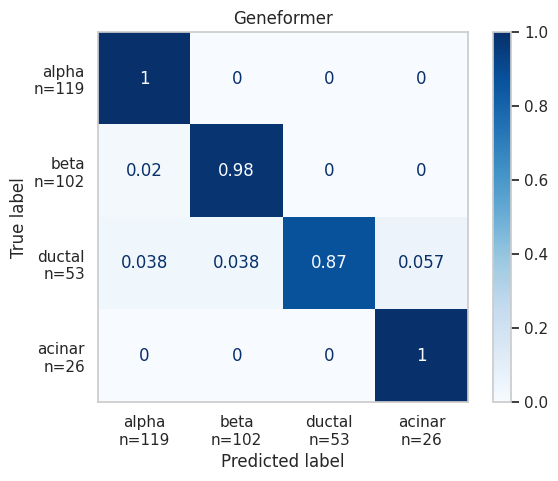

✅ Confusion matrix saved
❌ Predictions plot failed: [Errno 2] No such file or directory: '/content/pancreas_output/250730234459/pancreas_classifier_pred_dict.pkl'

🎉 ANALYSIS COMPLETE!
📁 Output: /content/pancreas_output/250730234459

📊 Generated files:
  🧠 pancreas_classifier_conf_mat.pdf
  📋 pancreas_classifier_test_test_metrics_dict.pkl
  📋 pancreas_classifier_labeled_train.dataset
  🧠 250730_geneformer_cellClassifier_pancreas_classifier
  📋 pancreas_classifier_id_class_dict.pkl
  📋 pancreas_classifier_labeled_test.dataset
  📋 pancreas_classifier_test_pred_dict.pkl

📈 BEST PERFORMANCE:
  Accuracy: 0.9700
  F1-Score: 0.9597

✅ Done! Check /content/pancreas_output/250730234459 for results.


In [ ]:
"""
Geneformer Fine-Tuning for Pancreas Cell Type Classification
Simplified Implementation with Direct Dataset Splitting
"""

import datetime
import os
import warnings
import numpy as np
from collections import Counter
from datasets import load_from_disk
from geneformer import Classifier

# Suppress warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# =============================================================================
# SETUP AND CONFIGURATION
# =============================================================================

print("🚀 Geneformer Pancreas Cell Type Classification")
print("="*50)

# Setup paths
current_date = datetime.datetime.now()
datestamp = f"{str(current_date.year)[-2:]}{current_date.month:02d}{current_date.day:02d}{current_date.hour:02d}{current_date.minute:02d}{current_date.second:02d}"
output_dir = f"/content/pancreas_output/{datestamp}"
output_prefix = "pancreas_classifier"
dataset_path = "/content/pancreas_shuffled_filtered_labeled_downsampled_fixednolabel.dataset"
model_path = "/content/Geneformer/Geneformer-V2-104M"

os.makedirs(output_dir, exist_ok=True)
print(f"📁 Output: {output_dir}")

# =============================================================================
# LOAD DATASET
# =============================================================================

print(f"\n📊 Loading dataset...")
dataset = load_from_disk(dataset_path)
print(f"✅ Loaded {len(dataset)} cells")

# Show cell type distribution
celltype_counts = Counter([example['celltype'] for example in dataset])
print(f"\n🏷️  Cell types:")
for celltype, count in celltype_counts.most_common():
    pct = 100 * count / len(dataset)
    print(f"  {celltype}: {count} ({pct:.1f}%)")

# =============================================================================
# CREATE SIMPLE SPLITS
# =============================================================================

print(f"\n📊 Creating splits...")

# Simple split function
def create_simple_splits(dataset, train_ratio=0.7, eval_ratio=0.15, test_ratio=0.15, random_state=42):
    """Create simple train/eval/test splits"""
    print(f"Splits: {train_ratio*100:.0f}% train, {eval_ratio*100:.0f}% eval, {test_ratio*100:.0f}% test")

    # Shuffle and split
    dataset = dataset.shuffle(seed=random_state)
    n_total = len(dataset)
    n_train = int(n_total * train_ratio)
    n_eval = int(n_total * eval_ratio)
    n_test = n_total - n_train - n_eval

    # Create split labels
    split_labels = ["train"] * n_train + ["eval"] * n_eval + ["test"] * n_test
    dataset = dataset.map(lambda example, idx: {"split": split_labels[idx]}, with_indices=True)

    return dataset

# Create splits
dataset = create_simple_splits(dataset)

# Show split distribution
split_counts = Counter([example["split"] for example in dataset])
print(f"\n📊 Split sizes:")
for split, count in split_counts.items():
    print(f"  {split}: {count} cells")

# Save dataset with splits
complete_dataset_path = f"{output_dir}/pancreas_with_splits_ready.dataset"
dataset.save_to_disk(complete_dataset_path)
print(f"✅ Saved dataset with splits")

# =============================================================================
# SETUP CLASSIFIER
# =============================================================================

print(f"\n🔧 Setting up classifier...")

# Training arguments
training_args = {
    "num_train_epochs": 0.9,
    "learning_rate": 0.0008,
    "lr_scheduler_type": "polynomial",
    "warmup_steps": 500,
    "weight_decay": 0.03,
    "per_device_train_batch_size": 8,
    "seed": 42,
    "gradient_checkpointing": False,
    "fp16": False,
}

# Initialize classifier
cc = Classifier(
    classifier="cell",
    cell_state_dict={"state_key": "celltype", "states": "all"},
    filter_data=None,  # Use all cell types
    training_args=training_args,
    max_ncells=None,
    freeze_layers=2,
    num_crossval_splits=1,
    forward_batch_size=8,
    nproc=16,
    ngpu=1
)

print("✅ Classifier ready")

# =============================================================================
# PREPARE DATA
# =============================================================================

print(f"\n📋 Preparing data...")

# Split dictionaries
train_test_split_dict = {"attr_key": "split", "train": ["train", "eval"], "test": ["test"]}
train_eval_split_dict = {"attr_key": "split", "train": ["train"], "eval": ["eval"]}

try:
    cc.prepare_data(
        input_data_file=complete_dataset_path,
        output_directory=output_dir,
        output_prefix=output_prefix,
        split_id_dict=train_test_split_dict
    )
    print("✅ Data prepared")
except Exception as e:
    print(f"❌ Data preparation failed: {e}")
    exit()

# =============================================================================
# TRAIN MODEL
# =============================================================================

print(f"\n🚀 Training model...")

prepared_dataset_file = f"{output_dir}/{output_prefix}_labeled_train.dataset"
id_class_dict_file = f"{output_dir}/{output_prefix}_id_class_dict.pkl"

try:
    training_metrics = cc.validate(
        model_directory=model_path,
        prepared_input_data_file=prepared_dataset_file,
        id_class_dict_file=id_class_dict_file,
        output_directory=output_dir,
        output_prefix=output_prefix,
        split_id_dict=train_eval_split_dict
    )
    print("✅ Training completed!")

    # Safely display training metrics
    accuracy = training_metrics.get('accuracy', 'N/A')
    macro_f1 = training_metrics.get('macro_f1', 'N/A')

    if isinstance(accuracy, (int, float)):
        print(f"📊 Training accuracy: {accuracy:.4f}")
    else:
        print(f"📊 Training accuracy: {accuracy}")

    if isinstance(macro_f1, (int, float)):
        print(f"📊 Training F1: {macro_f1:.4f}")
    else:
        print(f"📊 Training F1: {macro_f1}")

except Exception as e:
    print(f"❌ Training failed: {e}")
    exit()

# =============================================================================
# EVALUATE MODEL
# =============================================================================

print(f"\n🧪 Evaluating model...")

# Find trained model
model_dirs = [d for d in os.listdir(output_dir) if "geneformer_cellClassifier" in d and output_prefix in d]
if model_dirs:
    trained_model_dir = os.path.join(output_dir, model_dirs[0], "ksplit1")
    print(f"✅ Found model: {trained_model_dir}")
else:
    print("❌ Model not found")
    exit()

# Create evaluation classifier
eval_cc = Classifier(
    classifier="cell",
    cell_state_dict={"state_key": "celltype", "states": "all"},
    forward_batch_size=8,
    nproc=16
)

# Test files
test_data_file = f"{output_dir}/{output_prefix}_labeled_test.dataset"

try:
    all_metrics_test = eval_cc.evaluate_saved_model(
        model_directory=trained_model_dir,
        id_class_dict_file=id_class_dict_file,
        test_data_file=test_data_file,
        output_directory=output_dir,
        output_prefix=f"{output_prefix}_test"
    )
    print("✅ Evaluation completed!")

    # Show results
    print(f"\n📊 TEST RESULTS:")
    for key, value in all_metrics_test.items():
        if isinstance(value, (int, float)):
            print(f"  {key}: {value:.4f}")
        else:
            print(f"  {key}: {value}")

except Exception as e:
    print(f"❌ Evaluation failed: {e}")
    all_metrics_test = None

# =============================================================================
# CREATE PLOTS
# =============================================================================

if all_metrics_test:
    print(f"\n📊 Creating plots...")

    import matplotlib.pyplot as plt
    import seaborn as sns

    # Get unique cell types
    unique_celltypes = list(celltype_counts.keys())

    # Basic Geneformer plots
    try:
        eval_cc.plot_conf_mat(
            conf_mat_dict={"Geneformer": all_metrics_test["conf_matrix"]},
            output_directory=output_dir,
            output_prefix=output_prefix,
            custom_class_order=unique_celltypes,
        )
        print("✅ Confusion matrix saved")
    except Exception as e:
        print(f"❌ Confusion matrix failed: {e}")

    try:
        eval_cc.plot_predictions(
            predictions_file=f"{output_dir}/{output_prefix}_pred_dict.pkl",
            id_class_dict_file=f"{output_dir}/{output_prefix}_id_class_dict.pkl",
            title="Pancreas Cell Types",
            output_directory=output_dir,
            output_prefix=output_prefix,
            custom_class_order=unique_celltypes,
        )
        print("✅ Predictions plot saved")
    except Exception as e:
        print(f"❌ Predictions plot failed: {e}")

# =============================================================================
# FINAL SUMMARY
# =============================================================================

print(f"\n🎉 ANALYSIS COMPLETE!")
print("="*50)
print(f"📁 Output: {output_dir}")

# List files
print(f"\n📊 Generated files:")
for file in os.listdir(output_dir):
    if output_prefix in file:
        if any(x in file for x in ['.png']):
            print(f"  📊 {file}")
        elif any(x in file for x in ['.dataset', '.pkl']):
            print(f"  📋 {file}")
        else:
            print(f"  🧠 {file}")

# Show best metrics
if 'all_metrics_test' in locals() and all_metrics_test:
    print(f"\n📈 BEST PERFORMANCE:")
    accuracy_keys = [k for k in all_metrics_test.keys() if 'acc' in k.lower()]
    f1_keys = [k for k in all_metrics_test.keys() if 'f1' in k.lower()]

    if accuracy_keys:
        acc_key = accuracy_keys[0]
        print(f"  Accuracy: {all_metrics_test[acc_key]:.4f}")
    if f1_keys:
        f1_key = f1_keys[0]
        print(f"  F1-Score: {all_metrics_test[f1_key]:.4f}")

print(f"\n✅ Done! Check {output_dir} for results.")
print("="*50)